<a href="https://colab.research.google.com/github/froe0466/Microprocessors-2-Project/blob/master/OS14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Start HERE

### To Run this Notebook
1. Click "Runtime" dropdown, Select "Restart session and run all"
2. Upload spreadsheet -- it MUST be named 'OS14_PDF_Calculations.xlsx'
3. If there are any errors, read them, update the spredsheet and go back to step 1.

###Import Excel

In [1]:
from google.colab import files
import os
import re

print("Please upload your file:")
uploaded = files.upload()

for colab_filename, content in uploaded.items():
    # Detect if Colab appended " (1)", " (2)", etc., and strip it out to get the intended filename
    intended_filename = re.sub(r' \(\d+\)(?=\.[^.]+$|$)', '', colab_filename)

    # 1. If the old file exists, delete it
    if os.path.exists(intended_filename):
        os.remove(intended_filename)
        print(f'Deleted old version: "{intended_filename}"')

    # 2. If Colab saved a weird "file (1).csv" version to the disk, delete that too
    if colab_filename != intended_filename and os.path.exists(colab_filename):
        os.remove(colab_filename)

    # 3. Write the newly uploaded contents cleanly to the intended filename
    with open(intended_filename, 'wb') as f:
        f.write(content)

    print(f'Successfully saved new version as: "{intended_filename}" ({len(content)} bytes)')

print('\nFiles in current directory (/content/):')
!ls -F

Please upload your file:


Saving OS14_PDF_Calculations.xlsx to OS14_PDF_Calculations (2).xlsx
Deleted old version: "OS14_PDF_Calculations.xlsx"
Successfully saved new version as: "OS14_PDF_Calculations.xlsx" (20447 bytes)

Files in current directory (/content/):
 filename.csv			   OS14_PDF_Calculations.xlsx
'OS14_PDF_Calculations (1).xlsx'   sample_data/


## Inspect Data


In [2]:
import pandas as pd

# Load the Excel file
file_path = 'OS14_PDF_Calculations.xlsx'

# Read all sheets
xls_data = pd.read_excel(file_path, sheet_name=None)

# Access the first sheet
first_sheet_name = list(xls_data.keys())[0]
df_processed = xls_data[first_sheet_name]

# Display all rows and column info
print(f"\nAll rows of sheet '{first_sheet_name}':")
display(df_processed)

#Display unique metrics and probability distribution types
unique_metrics = df_processed['Metric'].unique()
unique_pdf_types = df_processed['PDF Type'].unique()

print("Unique Metrics:", unique_metrics)
print("Unique PDF Types:", unique_pdf_types)


All rows of sheet 'in':


,Architectural Decision,Option Name,Metric,PDF Type,Min,Mean,Max,SD,Relevant Research
0,Primary Deceleration,Rotary Propellers (Drone),Cost,Log-Normal,NaN,8.0,NaN,2.0,NaN
1,Primary Deceleration,Rotary Propellers (Drone),LTC,Beta-Right,3.5,4.5,5.5,NaN,NaN
2,Primary Deceleration,Aerodynamic Drag (Parachute),Cost,Normal,NaN,2.0,NaN,0.2,NaN
3,Primary Deceleration,Aerodynamic Drag (Parachute),LTC,Triangular,0.5,1.0,2.0,NaN,NaN
4,Primary Deceleration,Aerodynamic Lift (Fixed Wings),Cost,Normal,NaN,3.0,NaN,0.4,NaN
5,Primary Deceleration,Aerodynamic Lift (Fixed Wings),LTC,Triangular,2.0,3.0,4.0,NaN,NaN
6,Trajectory Guidance,Rotary Propellers (Drone),Cost,Log-Normal,NaN,8.0,NaN,2.0,NaN
7,Trajectory Guidance,Rotary Propellers (Drone),LTC,Triangular,3.5,5.0,5.5,NaN,NaN
8,Trajectory Guidance,Steerable Canopy (Actuators),Cost,Normal,NaN,2.0,NaN,0.3,NaN
9,Trajectory Guidance,Steerable Canopy (Actuators),LTC,Normal,NaN,2.0,NaN,0.2,NaN


Unique Metrics: ['Cost' 'LTC']
Unique PDF Types: ['Log-Normal' 'Beta-Right' 'Normal' 'Triangular' 'Uniform']


### Deftermine Possible Architectures:
Generate all valid architectural combinations, calculate their performance, and identify the pareto frontier.


In [3]:
import numpy as np
import pandas as pd
from typing import Sequence, Optional

### Common functions for determining Pareto Front ###

def pareto_mask(points: np.ndarray) -> np.ndarray:
    """
    Textbook O(N^2) Pareto domination check.
    Lower-is-better for all dimensions.
    """
    n = points.shape[0]
    mask = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            # j dominates i if j is better or equal in ALL dims,
            # AND strictly better in AT LEAST one dim.
            if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                mask[i] = False
                break  # i is dominated, stop checking and move on

    return mask


def pareto_frontier(
    df: pd.DataFrame,
    cols: Sequence[str],
    maximize: Optional[Sequence[bool]] = None
) -> pd.DataFrame:
    """
    Return DataFrame rows on Pareto frontier for `cols`.
    `maximize` flags per col (defaults to maximizing all).
    """
    if maximize is None:
        maximize = [True] * len(cols)

    if len(maximize) != len(cols):
        raise ValueError("The length of 'maximize' flags must match the length of 'cols'.")

    # CRITICAL FIX: Added .copy() to prevent modifying the original dataframe memory
    pts = df[list(cols)].to_numpy(dtype=float).copy()

    # Convert to lower-is-better
    for k, m in enumerate(maximize):
        if m:  # if maximize, negate column
            pts[:, k] = -pts[:, k]

    # Calculate mask and return filtered dataframe
    mask = pareto_mask(pts)
    return df[mask].copy()

    #--------------------------------------------------#


In [4]:
import itertools
import numpy as np
import pandas as pd
from typing import Sequence, Optional

# 1. Extract Architectural Decision categories and options
decisions = df_processed['Architectural Decision'].unique()
decision_options = {}

for decision in decisions:
    # Get unique options for this decision
    options = df_processed[df_processed['Architectural Decision'] == decision]['Option Name'].unique()
    decision_options[decision] = options

# 2. Generate all possible combinations
keys = decision_options.keys()
values = decision_options.values()
combinations = list(itertools.product(*values))

print(f"Total number of unique architectures: {len(combinations)}")

# 3. Calculate Deterministic Performance & Create DataFrame
arch_data = []

# Pre-filter df_processed for speed
cost_df = df_processed[df_processed['Metric'] == 'Cost'].set_index(['Architectural Decision', 'Option Name'])
ltc_df = df_processed[df_processed['Metric'] == 'LTC'].set_index(['Architectural Decision', 'Option Name'])

for i, combo in enumerate(combinations):
    total_cost = 0
    total_ltc = 0
    is_valid = True

    current_arch_dict = {'Arch_ID': i}

    for decision, option in zip(keys, combo):
        current_arch_dict[decision] = option

        # Add Cost
        try:
            val = cost_df.loc[(decision, option), 'Mean']
            if isinstance(val, pd.Series): val = val.iloc[0]

            # Strict check: If Mean is missing, fail loudly
            if pd.isna(val):
                raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option}' under decision '{decision}' (Metric: Cost).")
            else:
                total_cost += val
        except KeyError:
            pass # Perfectly fine, this option just doesn't affect Cost

        # Add LTC
        try:
            val = ltc_df.loc[(decision, option), 'Mean']
            if isinstance(val, pd.Series): val = val.iloc[0]

            # Strict check: If Mean is missing, fail loudly
            if pd.isna(val):
                raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option}' under decision '{decision}' (Metric: LTC).")
            else:
                total_ltc += val
        except KeyError:
            pass # Perfectly fine, this option just doesn't affect LTC (e.g., Asset Detachment)

    current_arch_dict['Total_Cost'] = total_cost if is_valid else np.nan
    current_arch_dict['Total_LTC'] = total_ltc if is_valid else np.nan
    arch_data.append(current_arch_dict)

df_architectures = pd.DataFrame(arch_data)


# # --- Normalize Valid Data ---
# valid_mask = df_architectures['Total_Cost'].notna() & df_architectures['Total_LTC'].notna()

# if valid_mask.any():
#     min_cost = df_architectures.loc[valid_mask, 'Total_Cost'].min()
#     max_cost = df_architectures.loc[valid_mask, 'Total_Cost'].max()

#     min_ltc = df_architectures.loc[valid_mask, 'Total_LTC'].min()
#     max_ltc = df_architectures.loc[valid_mask, 'Total_LTC'].max()

#     # Normalize Total_Cost to a 0-10 range
#     if max_cost > min_cost:
#         df_architectures.loc[valid_mask, 'Total_Cost'] = (
#             (df_architectures.loc[valid_mask, 'Total_Cost'] - min_cost) / (max_cost - min_cost) * 10.0
#         )

#     # Normalize Total_LTC to a 0-6 range
#     if max_ltc > min_ltc:
#         df_architectures.loc[valid_mask, 'Total_LTC'] = (
#             (df_architectures.loc[valid_mask, 'Total_LTC'] - min_ltc) / (max_ltc - min_ltc) * 6.0
#         )


# 4. Identify the Pareto Frontier
df_valid = df_architectures.dropna(subset=['Total_LTC', 'Total_Cost']).copy()

# Find the Pareto frontier on the valid data
front = pareto_frontier(df_valid, ['Total_LTC','Total_Cost'], maximize=[True, False])

# Update df_architectures
pareto_arch_ids = set(front['Arch_ID'].values)
df_architectures['is_pareto'] = df_architectures['Arch_ID'].isin(pareto_arch_ids)

print(f"Number of valid architectures evaluated: {len(df_valid)}")
print(f"Number of architectures on the Pareto frontier: {len(front)}")
display(front)

Total number of unique architectures: 324
Number of valid architectures evaluated: 324
Number of architectures on the Pareto frontier: 12


,Arch_ID,Primary Deceleration,Trajectory Guidance,Impact Mitigation,Ground Leveling,Asset Detachment,Total_Cost,Total_LTC
9,9,Rotary Propellers (Drone),Rotary Propellers (Drone),Crushable Base,Asset Self-leveling,Smart Ratchets,19.5,14.4
21,21,Rotary Propellers (Drone),Rotary Propellers (Drone),Precision Descent,Asset Self-leveling,Smart Ratchets,20.5,14.8
33,33,Rotary Propellers (Drone),Rotary Propellers (Drone),Dynamic Suspension,Asset Self-leveling,Smart Ratchets,21.5,15.8
45,45,Rotary Propellers (Drone),Steerable Canopy (Actuators),Crushable Base,Asset Self-leveling,Smart Ratchets,13.5,11.4
149,149,Aerodynamic Drag (Parachute),Steerable Canopy (Actuators),Crushable Base,Self-Righting Geometry,Smart Ratchets,7.0,3.6
153,153,Aerodynamic Drag (Parachute),Steerable Canopy (Actuators),Crushable Base,Asset Self-leveling,Smart Ratchets,7.5,7.9
225,225,Aerodynamic Lift (Fixed Wings),Rotary Propellers (Drone),Crushable Base,Asset Self-leveling,Smart Ratchets,14.5,12.9
237,237,Aerodynamic Lift (Fixed Wings),Rotary Propellers (Drone),Precision Descent,Asset Self-leveling,Smart Ratchets,15.5,13.3
249,249,Aerodynamic Lift (Fixed Wings),Rotary Propellers (Drone),Dynamic Suspension,Asset Self-leveling,Smart Ratchets,16.5,14.3
261,261,Aerodynamic Lift (Fixed Wings),Steerable Canopy (Actuators),Crushable Base,Asset Self-leveling,Smart Ratchets,8.5,9.9


### Visualize Architectures & Pareto Frontier

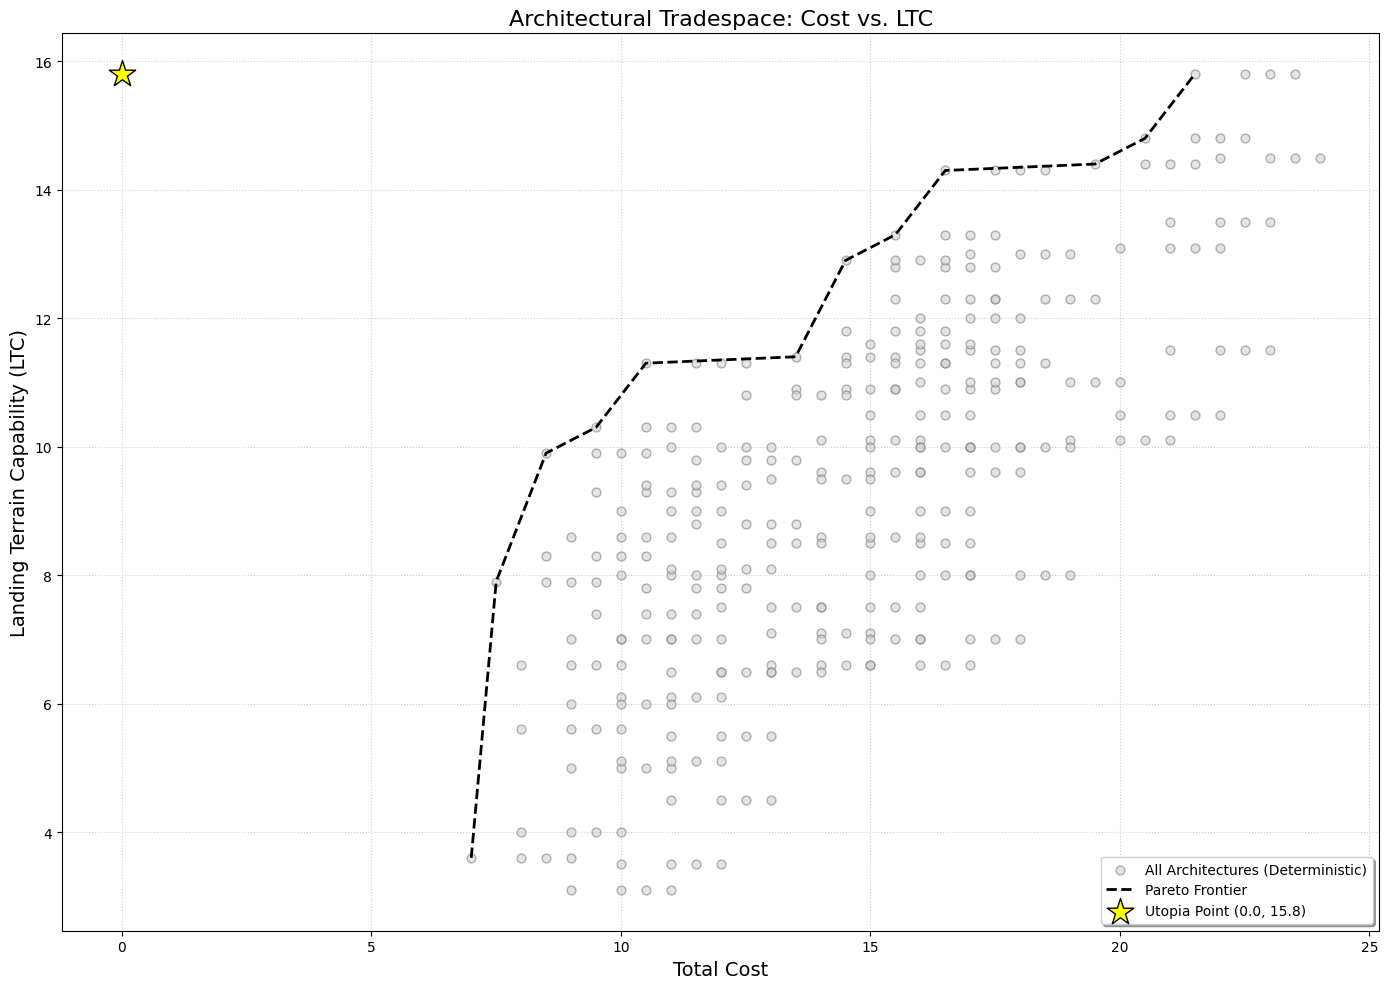

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14, 10))

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Pareto Frontier')

# 3. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_architectures['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

plt.title('Architectural Tradespace: Cost vs. LTC', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Select Architectures to Evaluate

Select 7 architectures (at random) from the pareto front.

In [6]:
import itertools

# 5. Select 7 Architectures
# Strategy: Pick Pareto points first, then sample remaining to get 7 total
selected_indices = []

# Get all Pareto indices
pareto_indices = df_architectures[df_architectures['is_pareto']].index.tolist()

#Randomly select 7 architectures from the pareto list
selected_indices = np.random.choice(pareto_indices, size=min(7, len(pareto_indices)), replace=False).tolist()

# Create a subset dataframe for the selected ones
selected_architectures = df_architectures.loc[selected_indices].copy()

print(f"Selected {len(selected_architectures)} architectures.")
display(selected_architectures[['Arch_ID', 'Total_Cost', 'Total_LTC', 'is_pareto']])

Selected 7 architectures.


,Arch_ID,Total_Cost,Total_LTC,is_pareto
9,9,19.5,14.4,True
21,21,20.5,14.8,True
225,225,14.5,12.9,True
261,261,8.5,9.9,True
149,149,7.0,3.6,True
273,273,9.5,10.3,True
285,285,10.5,11.3,True


## Calculate PDFs & Run Monte Carlo Simulation


In [7]:
import numpy as np
import pandas as pd

# Number of Monte Carlo samples
N_SAMPLES = 1000
np.random.seed(42)

# Dictionary to store simulation results for each selected architecture
simulation_results = {}

# Perform Simulation
for idx, row in selected_architectures.iterrows():
    arch_id = row['Arch_ID']

    # Initialize arrays for summing samples
    total_cost_samples = np.zeros(N_SAMPLES)
    total_ltc_samples = np.zeros(N_SAMPLES)

    # Iterate through each decision to get the specific option
    for decision in decisions:
        option_name = row[decision]

        components = df_processed[
            (df_processed['Architectural Decision'] == decision) &
            (df_processed['Option Name'] == option_name)
        ]

        for _, comp_row in components.iterrows():
            metric = comp_row['Metric']
            pdf_type = comp_row['PDF Type']

            # Read all required statistical columns (Base has been removed entirely)
            mean = comp_row['Mean']
            sd = comp_row['SD']
            left = comp_row['Min']
            right = comp_row['Max']

            # --- 1. NORMAL & LOG-NORMAL VALIDATION ---
            if pdf_type in ['Normal', 'Log-Normal']:
                if pd.isna(mean):
                    raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")
                if pd.isna(sd):
                    raise ValueError(f"Spreadsheet Error: Missing 'SD' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")

                if pdf_type == 'Normal':
                    samples = np.random.normal(mean, sd, N_SAMPLES)
                else: # Log-Normal
                    if mean <= 0:
                        samples = np.zeros(N_SAMPLES)
                    else:
                        var = sd**2
                        sigma2 = np.log(1 + (var / mean**2))
                        mu = np.log(mean) - sigma2 / 2
                        sigma = np.sqrt(sigma2)
                        samples = np.random.lognormal(mu, sigma, N_SAMPLES)

            # --- 2. TRIANGULAR VALIDATION ---
            elif pdf_type == 'Triangular':
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(mean): missing_cols.append('Mean (used as Mode)')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type 'Triangular'. Please populate these columns.")

                # Uses Mean as the mode (peak) of the triangle
                samples = np.random.triangular(left, mean, right, N_SAMPLES)

            # --- 3. UNIFORM VALIDATION ---
            elif pdf_type == 'Uniform':
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type 'Uniform'. Please populate these columns.")

                samples = np.random.uniform(left, right, N_SAMPLES)

            # --- 4. BETA-LEFT & BETA-RIGHT VALIDATION ---
            elif pdf_type in ['Beta-Left', 'Beta-Right']:
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(mean): missing_cols.append('Mean (used as Mode)')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'. Please populate these columns.")

                # Logical check for skewness: Beta-Right (Tail on right) should have Mean < Midpoint
                if pdf_type == 'Beta-Right' and mean > (left + right) / 2:
                    raise ValueError(f"Spreadsheet Error: '{option_name}' ({metric}) is labeled '{pdf_type}' but the Mean ({mean}) is on the right side of the range. For a right-skewed tail, the Mean should be < {(left + right) / 2}.")

                # Logical check for skewness: Beta-Left (Tail on left) should have Mean > Midpoint
                if pdf_type == 'Beta-Left' and mean < (left + right) / 2:
                    raise ValueError(f"Spreadsheet Error: '{option_name}' ({metric}) is labeled '{pdf_type}' but the Mean ({mean}) is on the left side of the range. For a left-skewed tail, the Mean should be > {(left + right) / 2}.")

                # PERT scaling formula for Beta parameters
                alpha = 1 + 4 * (mean - left) / (right - left)
                beta = 1 + 4 * (right - mean) / (right - left)
                samples = left + (right - left) * np.random.beta(alpha, beta, N_SAMPLES)

            # --- 5. FALLBACK / UNKNOWN PDF TYPE ---
            else:
                if pd.isna(mean):
                    raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option_name}' ({metric}). Unknown PDF Type: '{pdf_type}'.")
                samples = np.full(N_SAMPLES, mean)

            # Sum the results
            if metric == 'Cost':
                total_cost_samples += samples
            elif metric == 'LTC':
                total_ltc_samples += samples

    simulation_results[arch_id] = {
        'Cost_Samples': total_cost_samples,
        'LTC_Samples': total_ltc_samples,
        'is_pareto': row.get('is_pareto', False)
    }

print(f"Simulation completed for {len(simulation_results)} architectures with {N_SAMPLES} samples each.")

Simulation completed for 7 architectures with 1000 samples each.


## Determine Uncertainty Bands

Find "best' architectures on the new pareto frontier AND 'worst' architectures on the anti-pareto frontier.

In [8]:
##Generate New Pareto Frontier##

# 1. Create df_simulation_data. Transpose the data in the simulation_data array
rows = []
for aid, entry in simulation_results.items():
    n = np.asarray(entry['Cost_Samples']).size
    rows.append(pd.DataFrame({
        'Arch_ID': aid,
        'Sample_ID': [f"{aid}_{i}" for i in range(n)],
        'Sample_Order': np.arange(n),
        'Total_Cost': entry['Cost_Samples'],
        'Total_LTC': entry['LTC_Samples'],
    }))
df_simulation_data = pd.concat(rows, ignore_index=True)

# 2. Identify the Pareto and Anti-Pareto Frontiers

# Drop missing/NaN simulation samples to prevent them from breaking the math
df_valid_sim = df_simulation_data.dropna(subset=['Total_LTC', 'Total_Cost']).copy()

# Find the BEST Pareto frontier (Maximize 'Total_LTC', Minimize 'Total_Cost')
front = pareto_frontier(df_valid_sim, ['Total_LTC', 'Total_Cost'], maximize=[True, False])

# Find the WORST Anti-Pareto frontier (Minimize 'Total_LTC', Maximize 'Total_Cost')
# Notice how we just flipped the boolean flags!
anti_front = pareto_frontier(df_valid_sim, ['Total_LTC', 'Total_Cost'], maximize=[False, True])


# 3. Update df_simulation_data with both frontiers
pareto_sample_ids = set(front['Sample_ID'].values)
anti_pareto_sample_ids = set(anti_front['Sample_ID'].values)

# Apply the booleans to the main dataframe
df_simulation_data['is_new_pareto'] = df_simulation_data['Sample_ID'].isin(pareto_sample_ids)
df_simulation_data['anti_pareto_front'] = df_simulation_data['Sample_ID'].isin(anti_pareto_sample_ids)


# Display results
print(f"Total simulated samples: {len(df_simulation_data)}")
print(f"Valid samples evaluated: {len(df_valid_sim)}")
print(f"Samples on the Best (Pareto) frontier: {len(front)}")
print("\nBest Possible Architectures:")
display(front)

# Preview the absolute worst architectures
df_worst = df_simulation_data[df_simulation_data['anti_pareto_front']]
print(f"Samples on the Worst (Anti-Pareto) frontier: {len(anti_front)}")
print("\nWorst Possible Architectures:")
display(df_worst)

Total simulated samples: 7000
Valid samples evaluated: 7000
Samples on the Best (Pareto) frontier: 29

Best Possible Architectures:


,Arch_ID,Sample_ID,Sample_Order,Total_Cost,Total_LTC
13,9,9_13,13,13.794995,15.209709
44,9,9_44,44,13.572301,15.183111
815,9,9_815,815,12.980006,14.588893
1221,21,21_221,221,16.356969,15.612481
1585,21,21_585,585,21.070372,16.083017
1621,21,21_621,621,16.578493,15.640735
1658,21,21_658,658,20.216503,15.728951
1827,21,21_827,827,15.054632,15.474263
1841,21,21_841,841,18.416306,15.725587
1848,21,21_848,848,21.456242,16.280091


Samples on the Worst (Anti-Pareto) frontier: 29

Worst Possible Architectures:


,Arch_ID,Sample_ID,Sample_Order,Total_Cost,Total_LTC,is_new_pareto,anti_pareto_front
209,9,9_209,209,29.797435,13.045897,False,True
654,9,9_654,654,24.408062,12.309346,False,True
928,9,9_928,928,27.683766,12.858454,False,True
1118,21,21_118,118,22.745382,12.194096,False,True
1213,21,21_213,213,34.908109,13.062722,False,True
1559,21,21_559,559,25.285789,12.356677,False,True
2187,225,225_187,187,22.018308,11.846798,False,True
2514,225,225_514,514,20.651826,10.812514,False,True
3557,261,261_557,557,8.534315,8.135953,False,True
3689,261,261_689,689,9.007553,8.378455,False,True


###PDF Graphs

Selects one architecture from the 7 selected architectures on the original pareto front

Generating component PDF plots for Architecture: 9


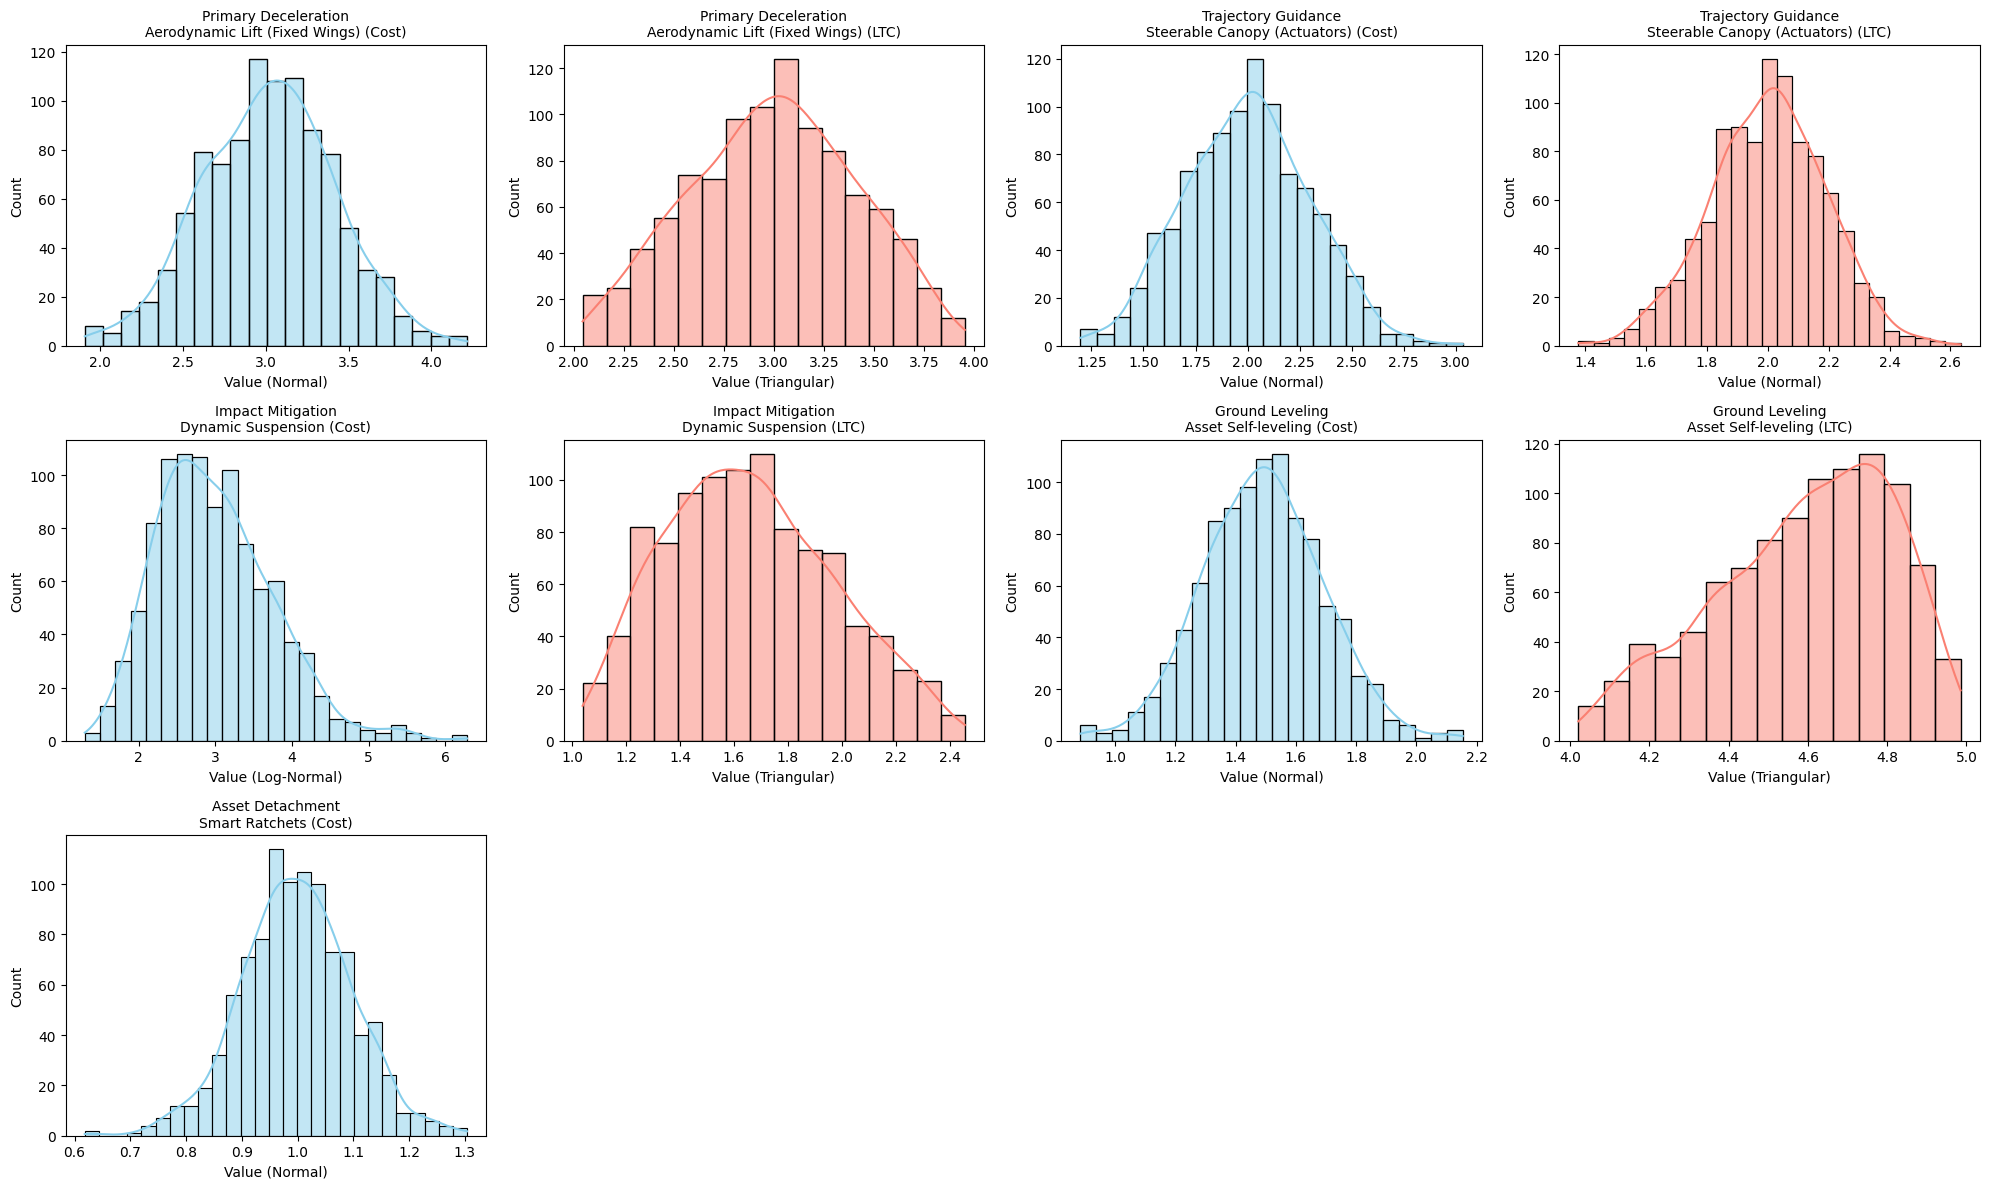

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# Pick the Arch_ID you want to inspect (e.g., the first one in selected_architectures)
target_arch_id = selected_architectures['Arch_ID'].iloc[0]

print(f"Generating component PDF plots for Architecture: {target_arch_id}")

# Determine grid size (number of decisions)
num_plots = len(decisions) * 2  # 2 metrics (Cost and LTC) per decision
cols = 4
rows = (num_plots // cols) + (1 if num_plots % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()
plot_idx = 0

# Iterate through decisions to plot individual component distributions
for decision in decisions:
    option_name = row[decision]
    components = df_processed[
        (df_processed['Architectural Decision'] == decision) &
        (df_processed['Option Name'] == option_name)
    ]

    for _, comp_row in components.iterrows():
        metric = comp_row['Metric']
        pdf_type = comp_row['PDF Type']
        mean, sd, left, right = comp_row['Mean'], comp_row['SD'], comp_row['Min'], comp_row['Max']

        # REGENERATE SAMPLES FOR PLOTTING
        if pdf_type == 'Normal':
            samples = np.random.normal(mean, sd, N_SAMPLES)
        elif pdf_type == 'Log-Normal':
            if mean > 0:
                var = sd**2
                sigma2 = np.log(1 + (var / mean**2))
                mu = np.log(mean) - sigma2 / 2
                sigma = np.sqrt(sigma2)
                samples = np.random.lognormal(mu, sigma, N_SAMPLES)
            else: samples = np.zeros(N_SAMPLES)
        elif pdf_type == 'Triangular':
            samples = np.random.triangular(left, mean, right, N_SAMPLES)
        elif pdf_type == 'Uniform':
            samples = np.random.uniform(left, right, N_SAMPLES)
        else:
            samples = np.full(N_SAMPLES, mean if not pd.isna(mean) else 0)

        # Plotting
        ax = axes[plot_idx]
        sns.histplot(samples, kde=True, ax=ax, color='skyblue' if metric == 'Cost' else 'salmon')
        ax.set_title(f"{decision}\n{option_name} ({metric})", fontsize=10)
        ax.set_xlabel(f"Value ({pdf_type})")

        plot_idx += 1

# Remove any empty subplots
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Graph Monte Carlo Simulation


##Option 1

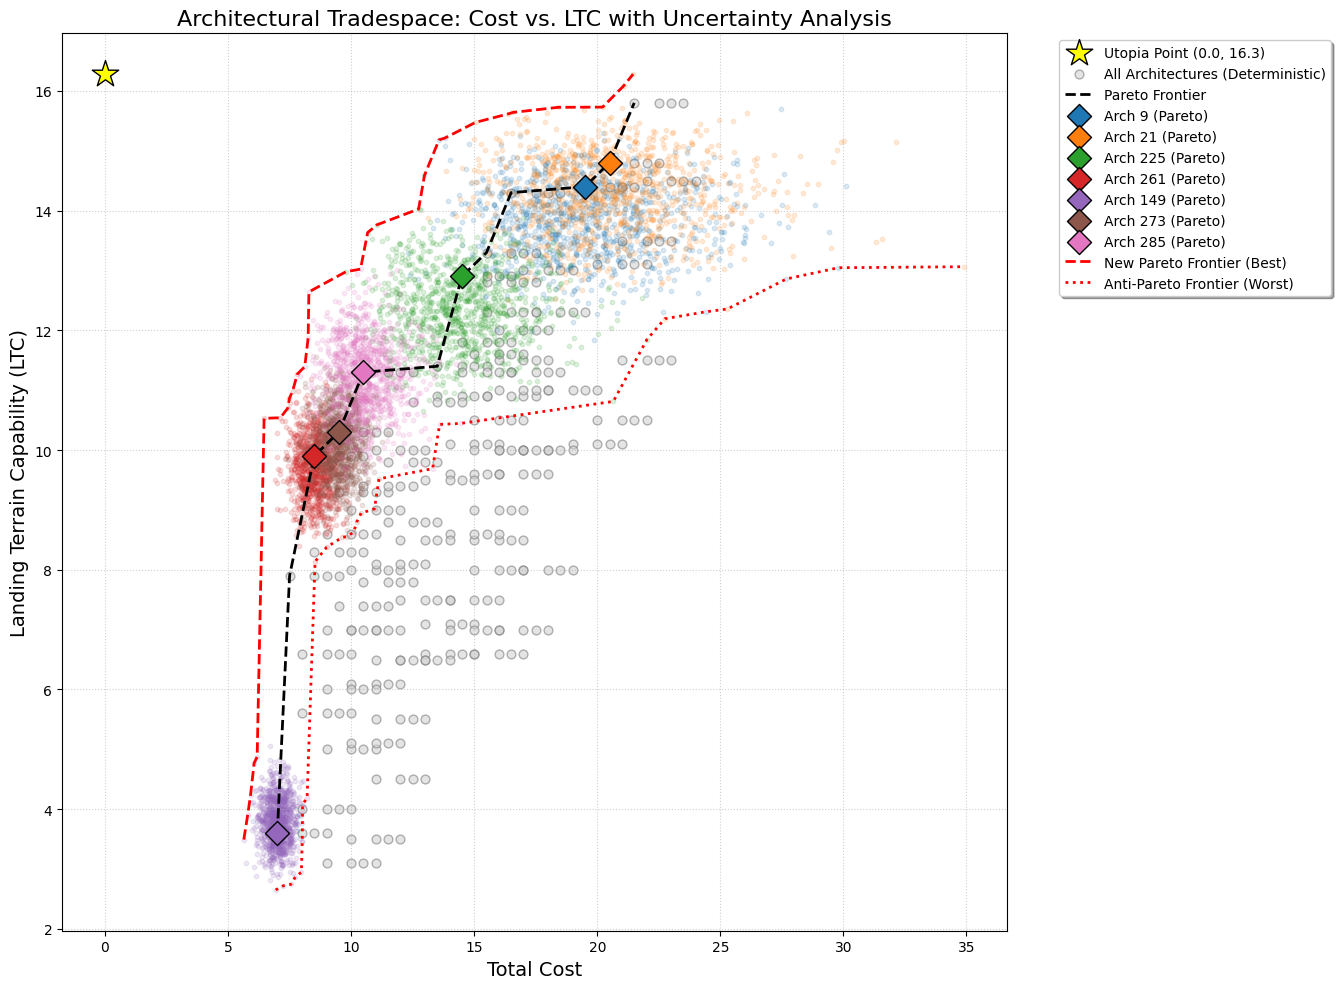

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14, 10))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Pareto Frontier')

# 3. Plot Simulation Results (Uncertainty Clouds)
# Use a color map to distinguish the 7 architectures
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Plot the MC samples (Uncertainty Region)
    plt.scatter(res['Cost_Samples'], res['LTC_Samples'],
                color=color, alpha=0.15, s=10)

    # Plot the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f'Arch {arch_id} {status_label}')

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='New Pareto Frontier (Best)')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle=':', linewidth=2, label='Anti-Pareto Frontier (Worst)')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 2

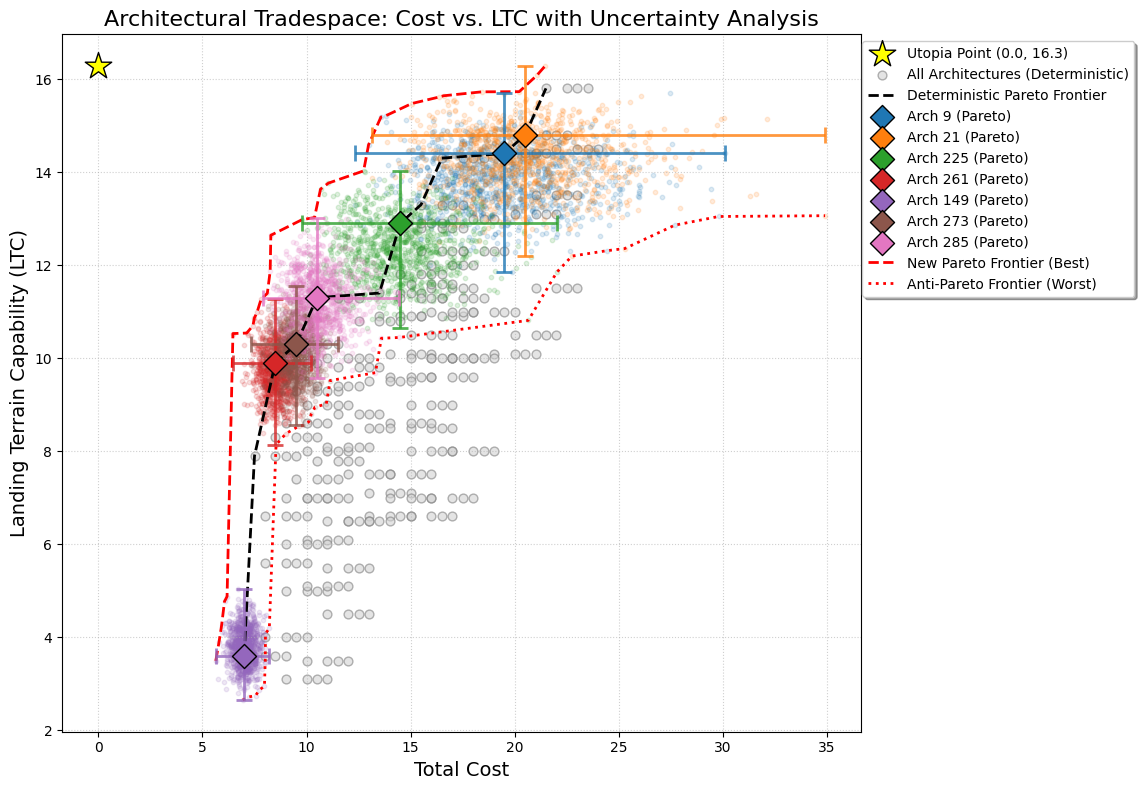

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Simulation Results (Uncertainty Clouds & Crosses)
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Plot the MC samples (Uncertainty Region cloud)
    plt.scatter(res['Cost_Samples'], res['LTC_Samples'],
                color=color, alpha=0.15, s=10)

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    # --- NEW: Calculate asymmetric distances for the cross lines ---
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    # Because the deterministic point might not be perfectly in the center,
    # we calculate the distance to the min and max edges individually.
    left_err = det_row['Total_Cost'] - min_cost
    right_err = max_cost - det_row['Total_Cost']
    bottom_err = det_row['Total_LTC'] - min_ltc
    top_err = max_ltc - det_row['Total_LTC']

    # Plot the "Cross of Jerusalem" (Error bars with end caps)
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)
    # -------------------------------------------------------------------

    # Plot the deterministic center point on top
    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f'Arch {arch_id} {status_label}')

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='New Pareto Frontier (Best)')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle=':', linewidth=2, label='Anti-Pareto Frontier (Worst)')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 3

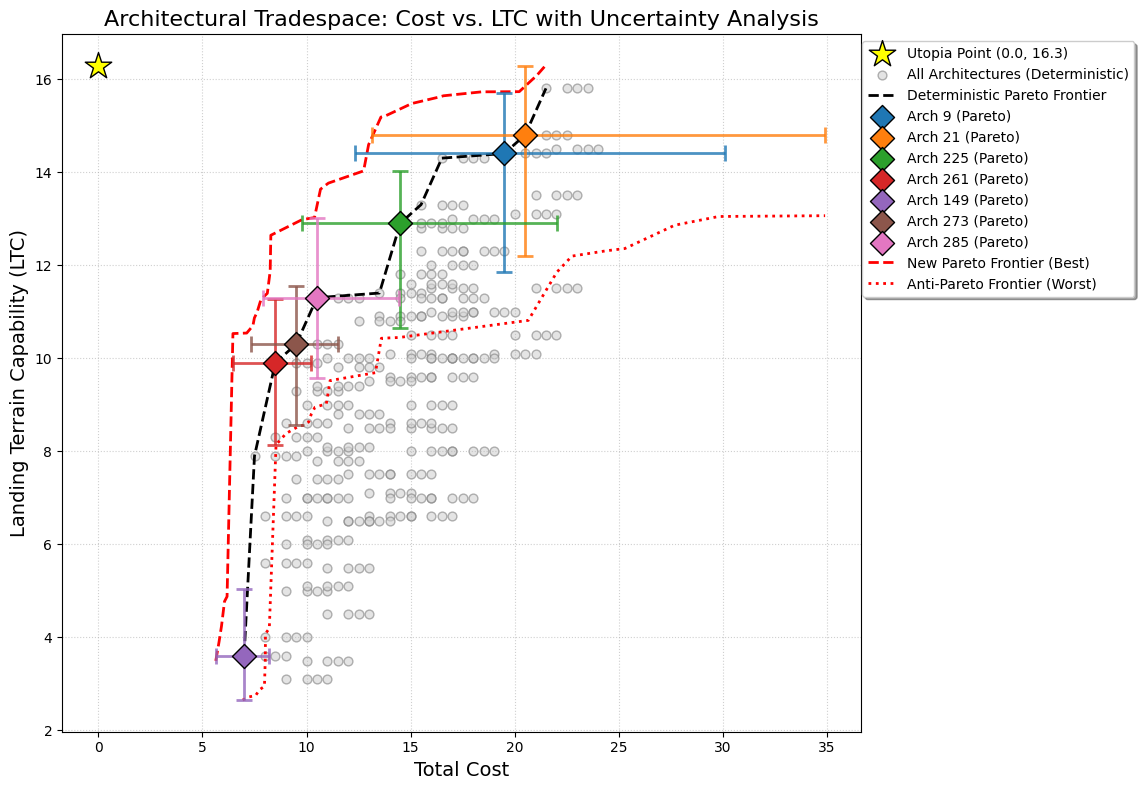

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Uncertainty Crosses (No Scatter Clouds)
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    # Calculate asymmetric distances for the cross lines
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    left_err = det_row['Total_Cost'] - min_cost
    right_err = max_cost - det_row['Total_Cost']
    bottom_err = det_row['Total_LTC'] - min_ltc
    top_err = max_ltc - det_row['Total_LTC']

    # Plot the "Cross of Jerusalem" (Error bars with end caps)
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)

    # Plot the deterministic center point on top
    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f'Arch {arch_id} {status_label}')

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='New Pareto Frontier (Best)')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle=':', linewidth=2, label='Anti-Pareto Frontier (Worst)')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 4

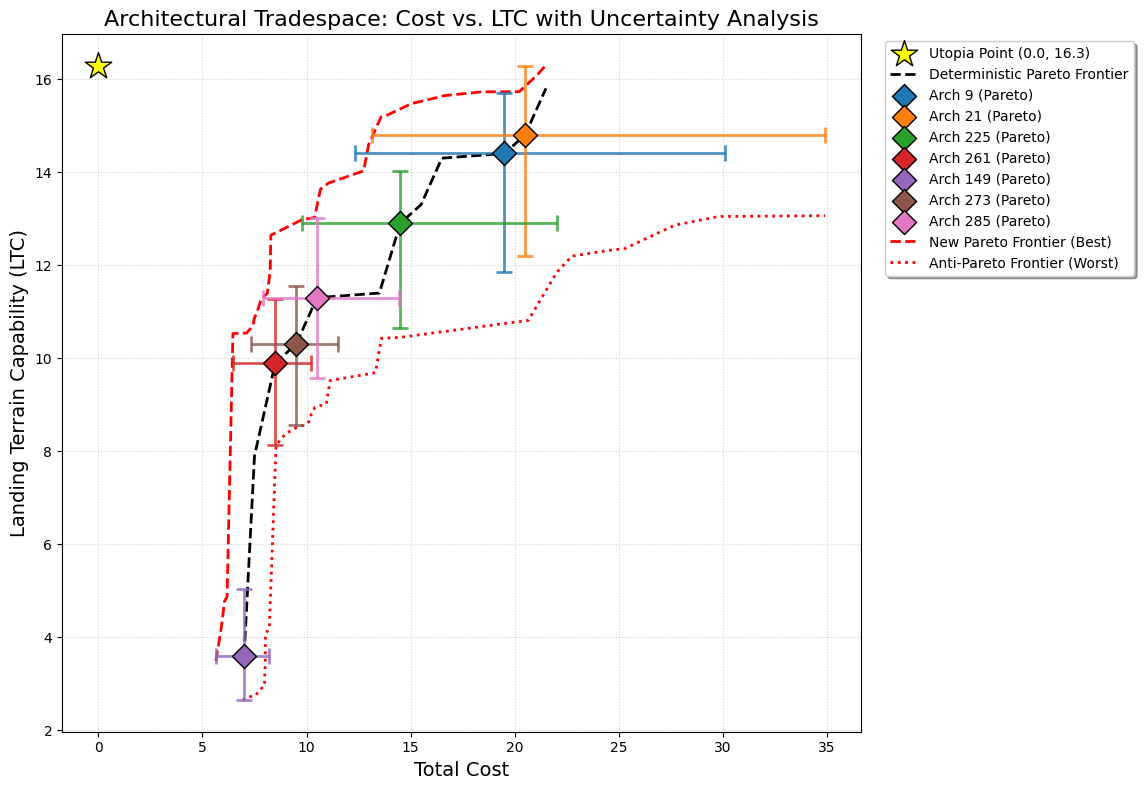

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# # 1. Plot all architectures (Deterministic Baseline)
# plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
#             c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Uncertainty Crosses (No Scatter Clouds)
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    # Calculate asymmetric distances for the cross lines
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    left_err = det_row['Total_Cost'] - min_cost
    right_err = max_cost - det_row['Total_Cost']
    bottom_err = det_row['Total_LTC'] - min_ltc
    top_err = max_ltc - det_row['Total_LTC']

    # Plot the "Cross of Jerusalem" (Error bars with end caps)
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)

    # Plot the deterministic center point on top
    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f'Arch {arch_id} {status_label}')

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='New Pareto Frontier (Best)')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle=':', linewidth=2, label='Anti-Pareto Frontier (Worst)')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 6

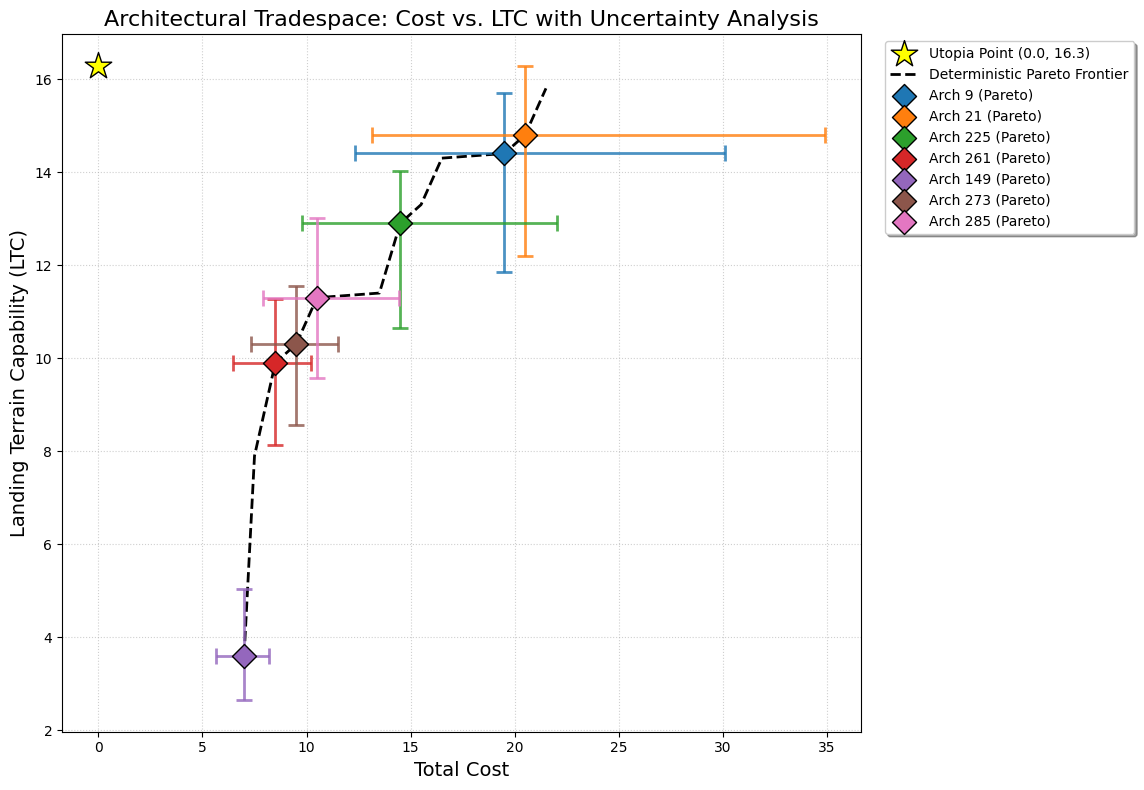

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Uncertainty Crosses (No Scatter Clouds)
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    # Calculate asymmetric distances for the cross lines
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    left_err = det_row['Total_Cost'] - min_cost
    right_err = max_cost - det_row['Total_Cost']
    bottom_err = det_row['Total_LTC'] - min_ltc
    top_err = max_ltc - det_row['Total_LTC']

    # Plot the "Cross of Jerusalem" (Error bars with end caps)
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)

    # Plot the deterministic center point on top
    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f'Arch {arch_id} {status_label}')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()